In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import interp2d
import datetime
from unwrap import unwrap
from scipy.interpolate import griddata

In [20]:
EWpol_NF_data = np.load('/hirax/20220916_WLC_NFandFF/NF_Map_220916_EWPol.npz',allow_pickle=True)
EWpol_NF_data.files

['t',
 'x',
 'y',
 'z',
 'V',
 'V_bgsub',
 'V_bg',
 'V_cross',
 'V_cross_bgsub',
 'V_cross_bg',
 'i_on',
 'f']

In [21]:
EWpol_NF_amplitude = np.sqrt(EWpol_NF_data['V_bgsub'])
EWpol_NF_phase = np.angle(EWpol_NF_data['V_cross_bgsub'])

EWpol_NF_complex = EWpol_NF_amplitude[:,:,1]*np.cos(EWpol_NF_phase[:,:,0]) + 1j*EWpol_NF_amplitude[:,:,1]*np.sin(EWpol_NF_phase[:,:,0])

<ipython-input-21-d902c576fc04>:1: RuntimeWarning: invalid value encountered in sqrt
  EWpol_NF_amplitude = np.sqrt(EWpol_NF_data['V_bgsub'])


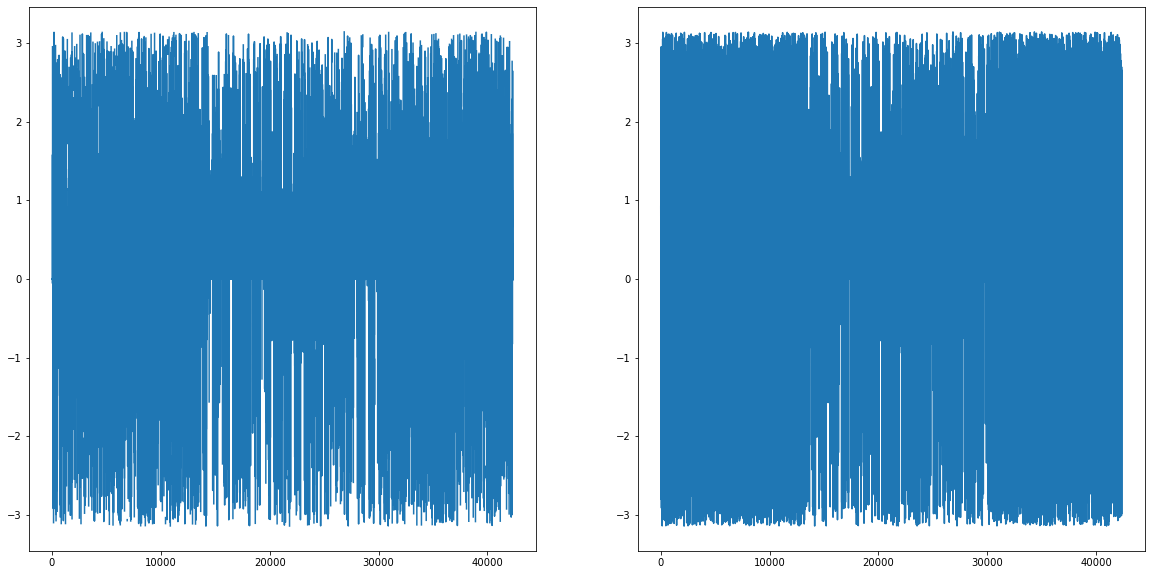

In [22]:
fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].plot(np.angle(EWpol_NF_complex[:,275]))
ax[1].plot(EWpol_NF_phase[:,275,0])

(42368,)


Text(0, 0.5, 'y position')

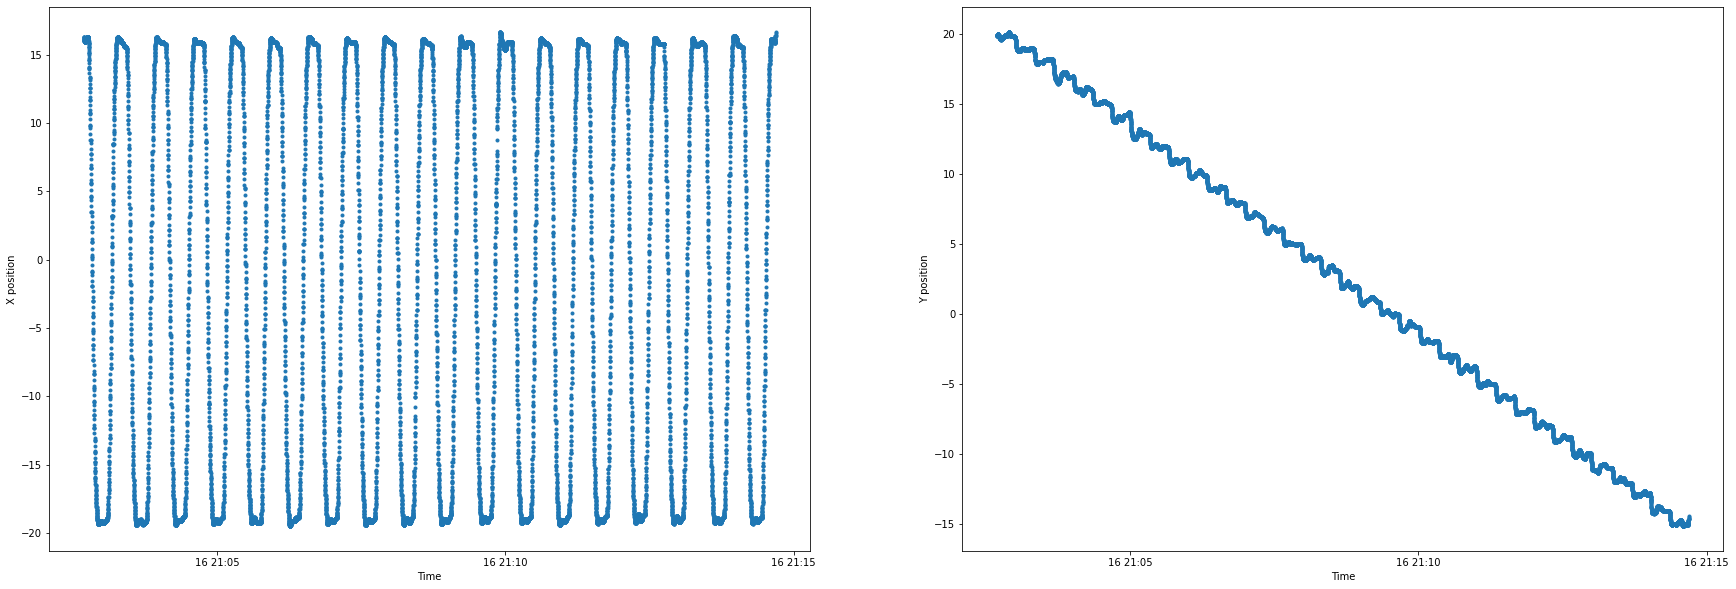

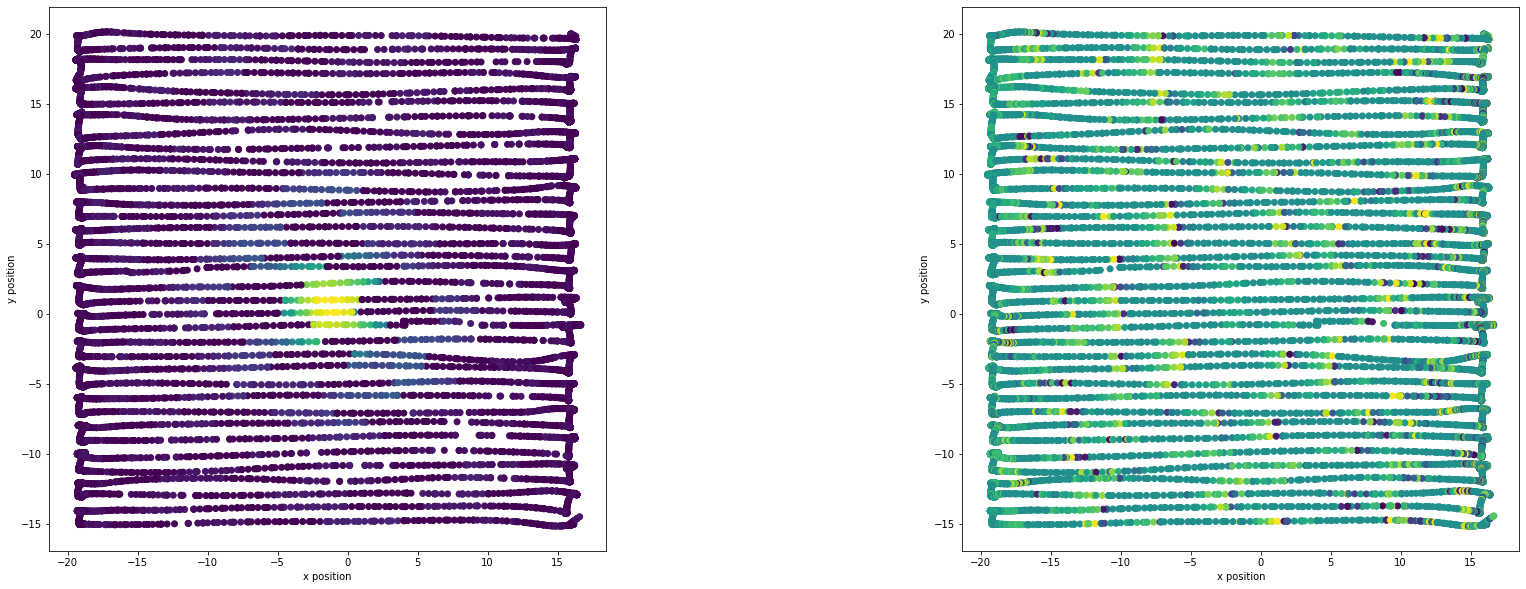

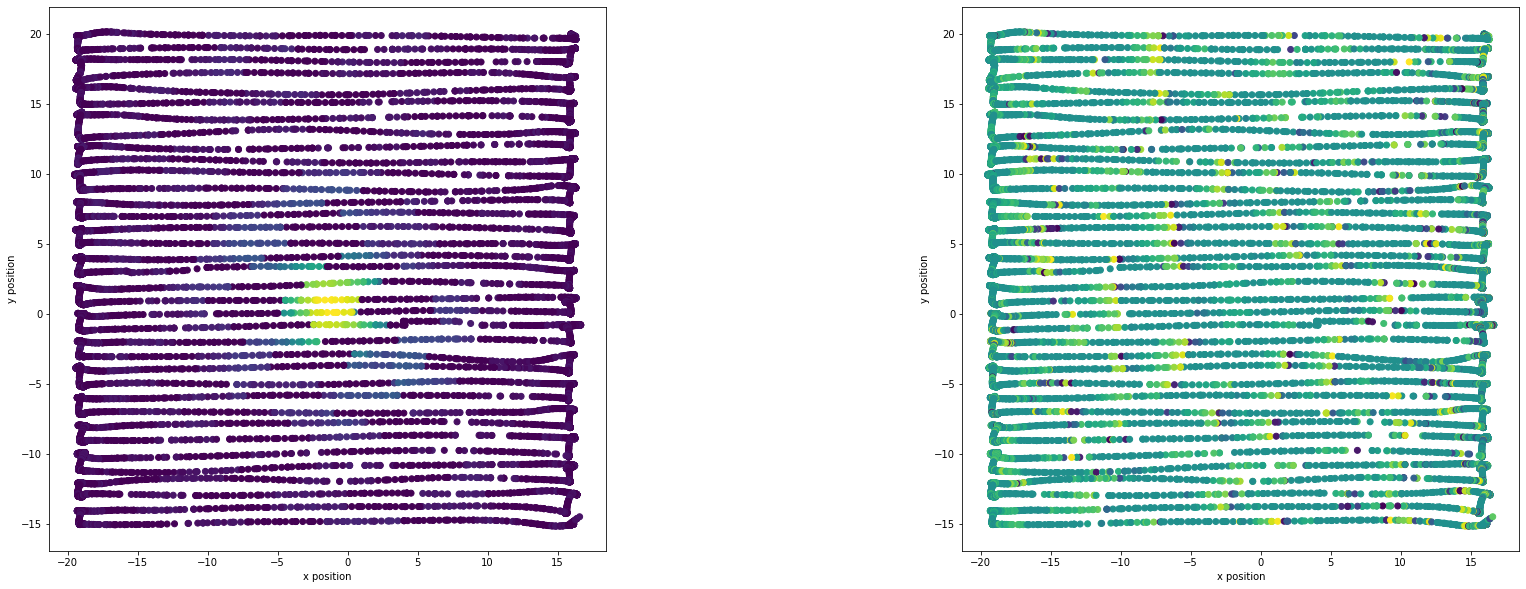

In [23]:
# plotting x and y position over time
print(EWpol_NF_data['t'].shape)

fig,ax = plt.subplots(1,2,figsize=(30,10))
ax[0].plot((EWpol_NF_data['t'])[13150:30310],(EWpol_NF_data['x'])[13150:30310],'.')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('X position')
ax[1].plot((EWpol_NF_data['t'])[13150:30310],(EWpol_NF_data['y'])[13150:30310],'.')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Y position')

fig = plt.figure(figsize=(30,10))
ax = fig.add_subplot(1,2,1)
ax.scatter((EWpol_NF_data['x'])[13150:30310],(EWpol_NF_data['y'])[13150:30310],c=(EWpol_NF_amplitude[13150:30310,275,1]))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax = fig.add_subplot(1,2,2)
ax.scatter((EWpol_NF_data['x'])[13150:30310],(EWpol_NF_data['y'])[13150:30310],c=EWpol_NF_phase[13150:30310,275])
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')

fig=plt.figure(figsize=(30,10))
ax = fig.add_subplot(1,2,1)
ax.scatter((EWpol_NF_data['x'])[13150:30310],(EWpol_NF_data['y'])[13150:30310],c=(np.abs(EWpol_NF_complex[13150:30310,275])))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax = fig.add_subplot(1,2,2)
ax.scatter((EWpol_NF_data['x'])[13150:30310],(EWpol_NF_data['y'])[13150:30310],c=np.angle(EWpol_NF_complex[13150:30310,275]))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')

Text(0, 0.5, 'y position')

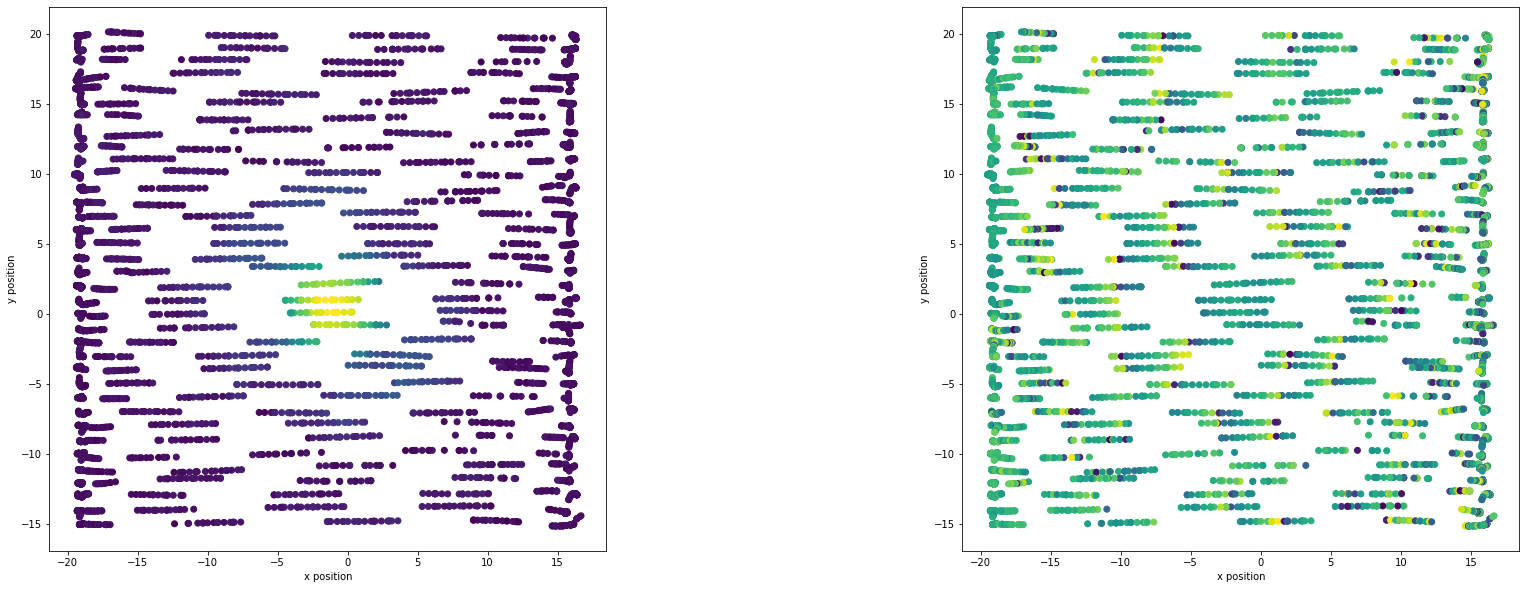

In [24]:
EWpol_NF_complex_grid = EWpol_NF_complex[13150:30310,:]
EWpol_t_grid = (EWpol_NF_data['t'])[13150:30310]
EWpol_x_grid = (EWpol_NF_data['x'])[13150:30310]
EWpol_y_grid = (EWpol_NF_data['y'])[13150:30310]
EWpol_z_grid = (EWpol_NF_data['z'])[13150:30310]

EWpol_i_on = EWpol_NF_data['i_on']
EWpol_grid_i_on=[]
for ind in EWpol_i_on:
    if (ind >= 13150) & (ind <= 30310):
        EWpol_grid_i_on.append(ind)

EWpol_NF_complex_grid_selected = EWpol_NF_complex[EWpol_grid_i_on]
EWpol_t_grid_selected = (EWpol_NF_data['t'])[EWpol_grid_i_on]
EWpol_x_grid_selected = (EWpol_NF_data['x'])[EWpol_grid_i_on]
EWpol_y_grid_selected = (EWpol_NF_data['y'])[EWpol_grid_i_on]
EWpol_z_grid_selected = (EWpol_NF_data['z'])[EWpol_grid_i_on]

fig=plt.figure(figsize=(30,10))
ax = fig.add_subplot(1,2,1)
ax.scatter(EWpol_x_grid_selected,EWpol_y_grid_selected,c=np.abs(EWpol_NF_complex_grid_selected[:,275]))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax = fig.add_subplot(1,2,2)
ax.scatter(EWpol_x_grid_selected,EWpol_y_grid_selected,c=np.angle(EWpol_NF_complex_grid_selected[:,275]))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')

In [25]:
EWpol_NF_real_grid = np.nan_to_num(EWpol_NF_complex_grid.real)
EWpol_NF_im_grid = np.nan_to_num(EWpol_NF_complex_grid.imag)

EWpol_NF_real_grid_selected = np.nan_to_num(EWpol_NF_complex_grid_selected.real)
EWpol_NF_im_grid_selected = np.nan_to_num(EWpol_NF_complex_grid_selected.imag)

x_interp = np.linspace(-15,15,50)
y_interp = np.linspace(-15,15,50)

[x_interp_grid,y_interp_grid]=np.meshgrid(x_interp,y_interp)

EWpol_NF_real_interp = griddata((EWpol_x_grid,EWpol_y_grid),EWpol_NF_real_grid[:,275],(x_interp_grid,y_interp_grid))
EWpol_NF_im_interp = griddata((EWpol_x_grid,EWpol_y_grid),EWpol_NF_im_grid[:,275],(x_interp_grid,y_interp_grid))

EWpol_NF_real_interp_selected = griddata((EWpol_x_grid_selected,EWpol_y_grid_selected),EWpol_NF_real_grid_selected[:,275],(x_interp_grid,y_interp_grid))
EWpol_NF_im_interp_selected = griddata((EWpol_x_grid_selected,EWpol_y_grid_selected),EWpol_NF_im_grid_selected[:,275],(x_interp_grid,y_interp_grid))

In [26]:
EWpol_NF_interped = EWpol_NF_real_interp + 1j*EWpol_NF_im_interp
EWpol_NF_interped_amplitude = np.abs(EWpol_NF_interped)
EWpol_NF_interped_phase = np.angle(EWpol_NF_interped)

EWpol_NF_interped_selected = EWpol_NF_real_interp_selected + 1j*EWpol_NF_im_interp_selected
EWpol_NF_interped_amplitude_selected = np.abs(EWpol_NF_interped_selected)
EWpol_NF_interped_phase_selected = np.angle(EWpol_NF_interped_selected)

<ipython-input-27-ca283133c45b>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(x_interp_grid,y_interp_grid,EWpol_NF_interped_amplitude)
<ipython-input-27-ca283133c45b>:18: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(x_interp_grid,y_interp_grid,EWpol_NF_interped_phase)
<ipython-input-27-ca283133c45b>:30: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either spec

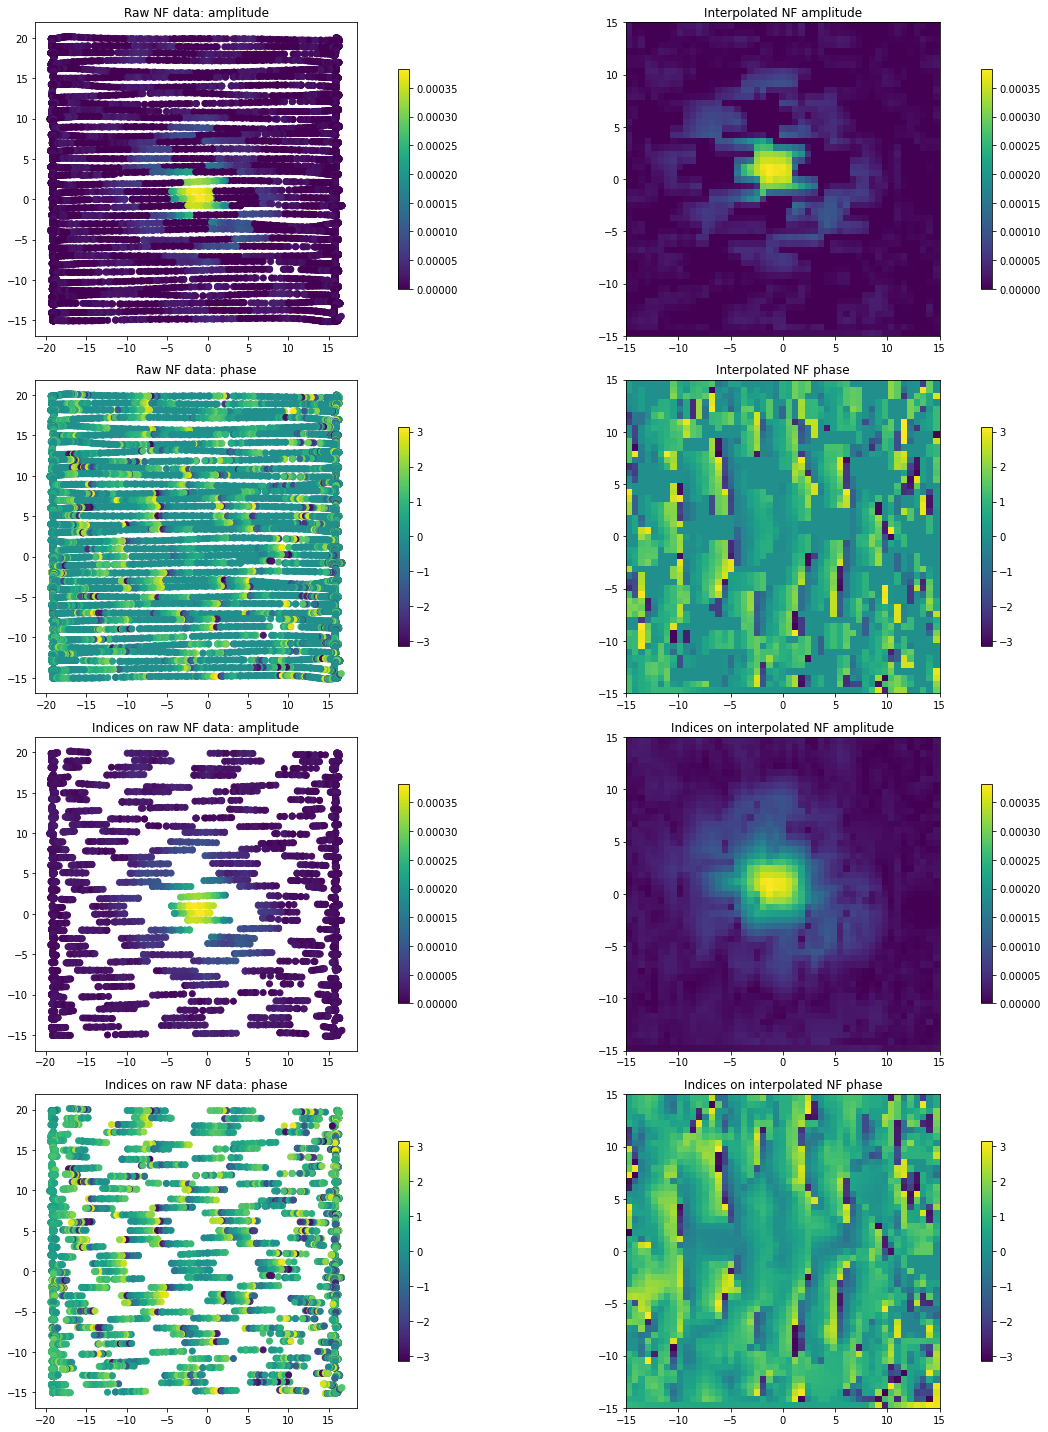

In [27]:
fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(4,2,1)
plt.scatter(EWpol_x_grid,EWpol_y_grid,c=np.abs(EWpol_NF_complex_grid[:,275]))
ax.set_aspect('equal')
plt.colorbar(shrink=0.7)
plt.title('Raw NF data: amplitude')
ax = fig.add_subplot(4,2,2)
ax.pcolormesh(x_interp_grid,y_interp_grid,EWpol_NF_interped_amplitude)
plt.title('Interpolated NF amplitude')
plt.colorbar(shrink=0.7)
ax.set_aspect('equal')
ax = fig.add_subplot(4,2,3)
plt.scatter(EWpol_x_grid,EWpol_y_grid,c=np.angle(EWpol_NF_complex_grid[:,275]))
ax.set_aspect('equal')
plt.colorbar(shrink=0.7)
plt.title('Raw NF data: phase')
ax = fig.add_subplot(4,2,4)
ax.pcolormesh(x_interp_grid,y_interp_grid,EWpol_NF_interped_phase)
plt.title('Interpolated NF phase')
plt.colorbar(shrink=0.7)
ax.set_aspect('equal')
plt.tight_layout()

ax = fig.add_subplot(4,2,5)
plt.scatter(EWpol_x_grid_selected,EWpol_y_grid_selected,c=np.abs(EWpol_NF_complex_grid_selected[:,275]))
ax.set_aspect('equal')
plt.colorbar(shrink=0.7)
plt.title('Indices on raw NF data: amplitude')
ax = fig.add_subplot(4,2,6)
ax.pcolormesh(x_interp_grid,y_interp_grid,EWpol_NF_interped_amplitude_selected)
plt.title('Indices on interpolated NF amplitude')
plt.colorbar(shrink=0.7)
ax.set_aspect('equal')
ax = fig.add_subplot(4,2,7)
plt.scatter(EWpol_x_grid_selected,EWpol_y_grid_selected,c=np.angle(EWpol_NF_complex_grid_selected[:,275]))
ax.set_aspect('equal')
plt.colorbar(shrink=0.7)
plt.title('Indices on raw NF data: phase')
ax = fig.add_subplot(4,2,8)
ax.pcolormesh(x_interp_grid,y_interp_grid,EWpol_NF_interped_phase_selected)
plt.title('Indices on interpolated NF phase')
plt.colorbar(shrink=0.7)
ax.set_aspect('equal')
plt.tight_layout()

plt.savefig('EWPol_NF_interpolated.jpg')

In [28]:
# bringing in NS pol

NSpol_NF_data = np.load('/hirax/20220916_WLC_NFandFF/NF_Map_220916_NSPol.npz',allow_pickle=True)
NSpol_NF_data.files

['t',
 'x',
 'y',
 'z',
 'V',
 'V_bgsub',
 'V_bg',
 'V_cross',
 'V_cross_bgsub',
 'V_cross_bg',
 'i_on',
 'f']

In [29]:
NSpol_NF_amplitude = np.sqrt(NSpol_NF_data['V_bgsub'])
NSpol_NF_phase = np.angle(NSpol_NF_data['V_cross_bgsub'])

NSpol_NF_complex = NSpol_NF_amplitude[:,:,1]*np.cos(NSpol_NF_phase[:,:,0]) + 1j*NSpol_NF_amplitude[:,:,1]*np.sin(NSpol_NF_phase[:,:,0])

<ipython-input-29-5d4099d53086>:1: RuntimeWarning: invalid value encountered in sqrt
  NSpol_NF_amplitude = np.sqrt(NSpol_NF_data['V_bgsub'])


(48576,)


Text(0, 0.5, 'y position')

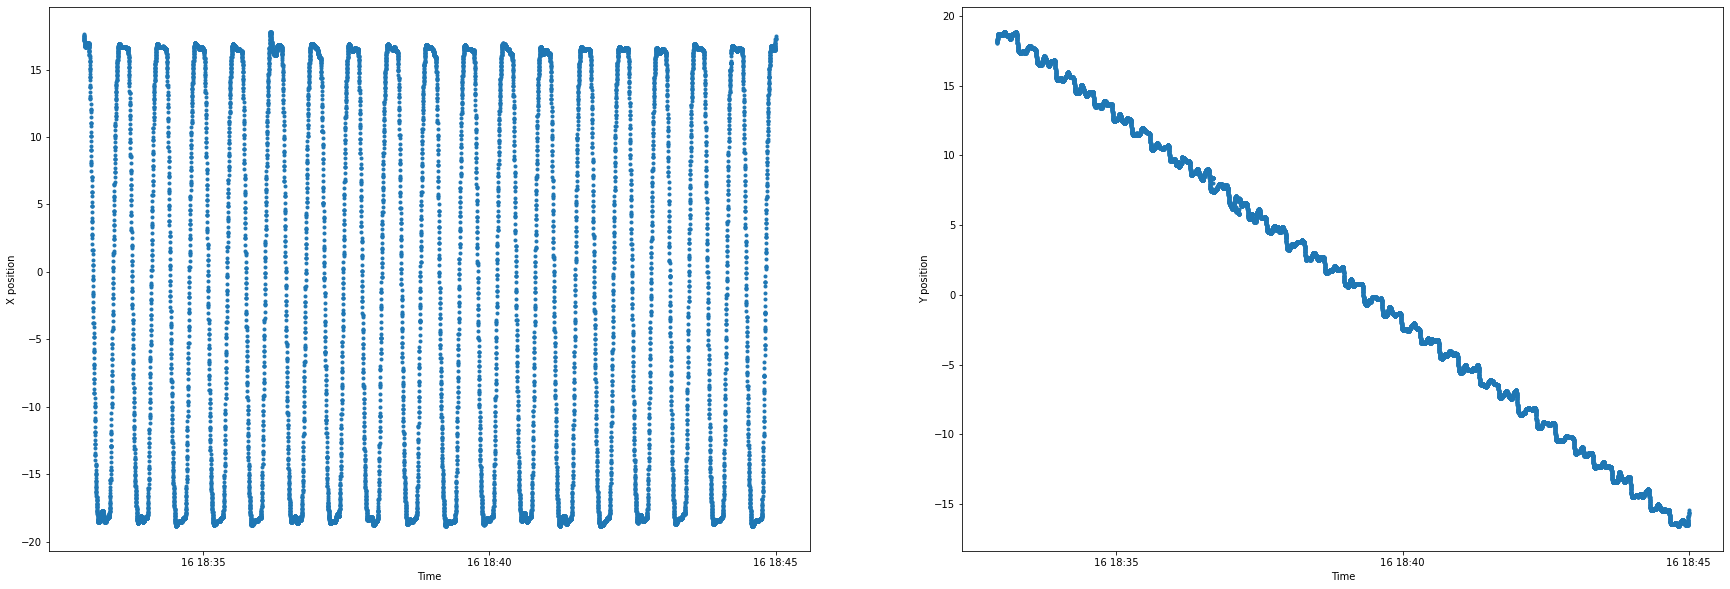

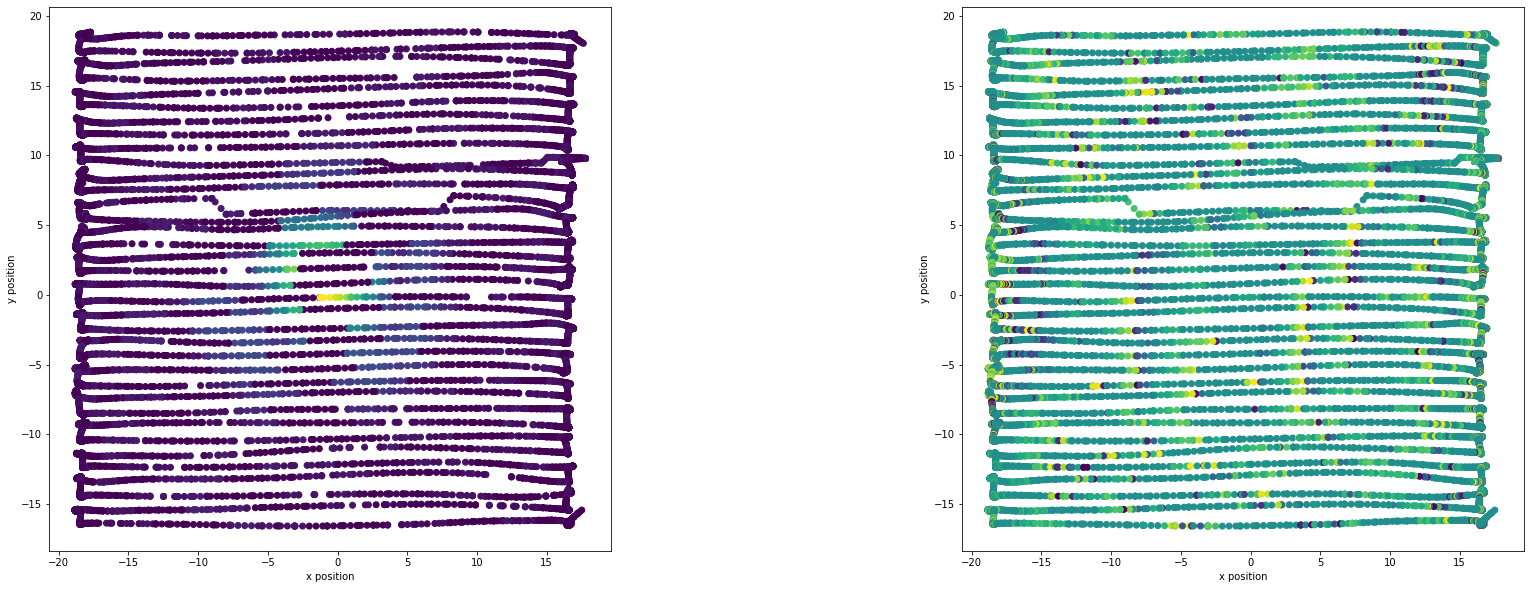

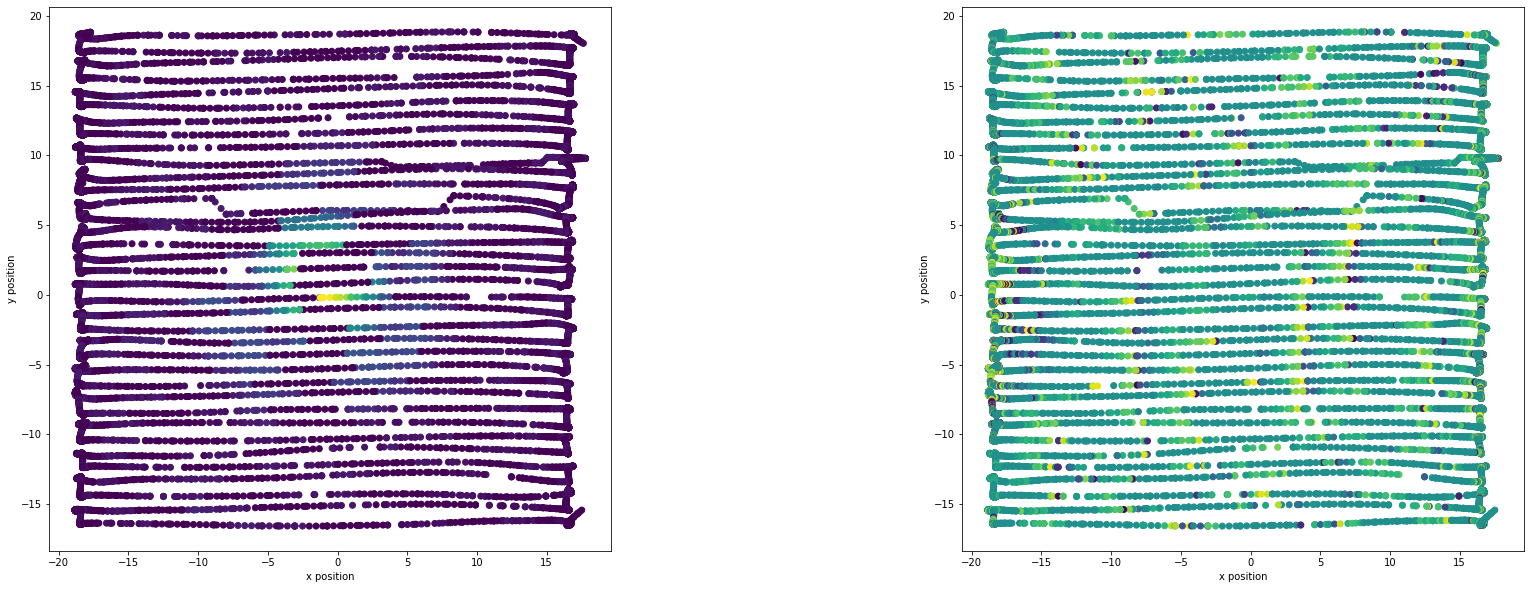

In [30]:
# plotting x and y position over time
print(NSpol_NF_data['t'].shape)

fig,ax = plt.subplots(1,2,figsize=(30,10))
ax[0].plot((NSpol_NF_data['t'])[19450:36740],(NSpol_NF_data['x'])[19450:36740],'.')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('X position')
ax[1].plot((NSpol_NF_data['t'])[19450:36740],(NSpol_NF_data['y'])[19450:36740],'.')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Y position')

fig = plt.figure(figsize=(30,10))
ax = fig.add_subplot(1,2,1)
ax.scatter((NSpol_NF_data['x'])[19450:36740],(NSpol_NF_data['y'])[19450:36740],c=(NSpol_NF_amplitude[19450:36740,275,1]))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax = fig.add_subplot(1,2,2)
ax.scatter((NSpol_NF_data['x'])[19450:36740],(NSpol_NF_data['y'])[19450:36740],c=NSpol_NF_phase[19450:36740,275])
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')

fig=plt.figure(figsize=(30,10))
ax = fig.add_subplot(1,2,1)
ax.scatter((NSpol_NF_data['x'])[19450:36740],(NSpol_NF_data['y'])[19450:36740],c=(np.abs(NSpol_NF_complex[19450:36740,275])))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax = fig.add_subplot(1,2,2)
ax.scatter((NSpol_NF_data['x'])[19450:36740],(NSpol_NF_data['y'])[19450:36740],c=np.angle(NSpol_NF_complex[19450:36740,275]))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')

Text(0, 0.5, 'y position')

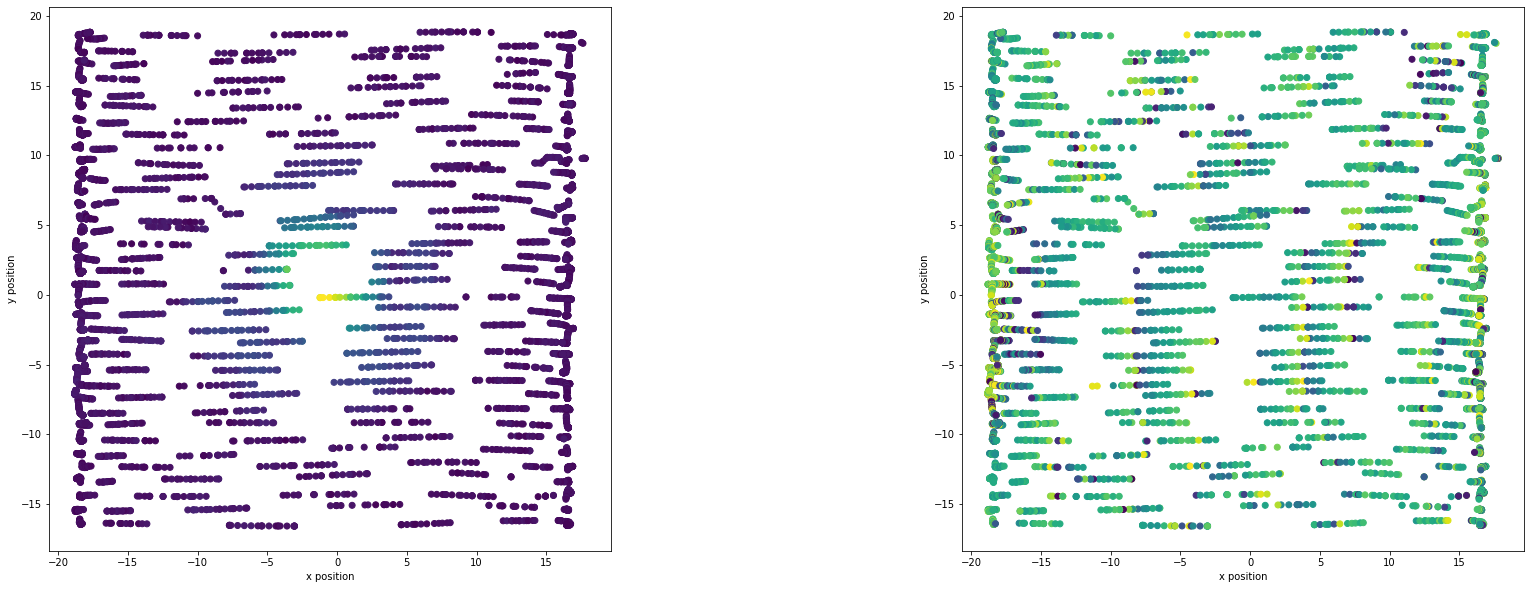

In [31]:
NSpol_NF_complex_grid = NSpol_NF_complex[19450:36740,:]
NSpol_t_grid = (NSpol_NF_data['t'])[19450:36740]
NSpol_x_grid = (NSpol_NF_data['x'])[19450:36740]
NSpol_y_grid = (NSpol_NF_data['y'])[19450:36740]
NSpol_z_grid = (NSpol_NF_data['z'])[19450:36740]

NSpol_i_on = NSpol_NF_data['i_on']
NSpol_grid_i_on=[]
for ind in NSpol_i_on:
    if (ind >= 19450) & (ind <= 36740):
        NSpol_grid_i_on.append(ind)

NSpol_NF_complex_grid_selected = NSpol_NF_complex[NSpol_grid_i_on]
NSpol_t_grid_selected = (NSpol_NF_data['t'])[NSpol_grid_i_on]
NSpol_x_grid_selected = (NSpol_NF_data['x'])[NSpol_grid_i_on]
NSpol_y_grid_selected = (NSpol_NF_data['y'])[NSpol_grid_i_on]
NSpol_z_grid_selected = (NSpol_NF_data['z'])[NSpol_grid_i_on]

fig=plt.figure(figsize=(30,10))
ax = fig.add_subplot(1,2,1)
ax.scatter(NSpol_x_grid_selected,NSpol_y_grid_selected,c=np.abs(NSpol_NF_complex_grid_selected[:,275]))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax = fig.add_subplot(1,2,2)
ax.scatter(NSpol_x_grid_selected,NSpol_y_grid_selected,c=np.angle(NSpol_NF_complex_grid_selected[:,275]))
ax.set_aspect('equal')
ax.set_xlabel('x position')
ax.set_ylabel('y position')

In [32]:
NSpol_NF_real_grid = np.nan_to_num(NSpol_NF_complex_grid.real)
NSpol_NF_im_grid = np.nan_to_num(NSpol_NF_complex_grid.imag)

NSpol_NF_real_grid_selected = np.nan_to_num(NSpol_NF_complex_grid_selected.real)
NSpol_NF_im_grid_selected = np.nan_to_num(NSpol_NF_complex_grid_selected.imag)

x_interp = np.linspace(-15,15,50)
y_interp = np.linspace(-15,15,50)

[x_interp_grid,y_interp_grid]=np.meshgrid(x_interp,y_interp)

NSpol_NF_real_interp = griddata((NSpol_x_grid,NSpol_y_grid),NSpol_NF_real_grid[:,275],(x_interp_grid,y_interp_grid))
NSpol_NF_im_interp = griddata((NSpol_x_grid,NSpol_y_grid),NSpol_NF_im_grid[:,275],(x_interp_grid,y_interp_grid))

NSpol_NF_real_interp_selected = griddata((NSpol_x_grid_selected,NSpol_y_grid_selected),NSpol_NF_real_grid_selected[:,275],(x_interp_grid,y_interp_grid))
NSpol_NF_im_interp_selected = griddata((NSpol_x_grid_selected,NSpol_y_grid_selected),NSpol_NF_im_grid_selected[:,275],(x_interp_grid,y_interp_grid))

In [33]:
NSpol_NF_interped = NSpol_NF_real_interp + 1j*NSpol_NF_im_interp
NSpol_NF_interped_amplitude = np.abs(NSpol_NF_interped)
NSpol_NF_interped_phase = np.angle(NSpol_NF_interped)

NSpol_NF_interped_selected = NSpol_NF_real_interp_selected + 1j*NSpol_NF_im_interp_selected
NSpol_NF_interped_amplitude_selected = np.abs(NSpol_NF_interped_selected)
NSpol_NF_interped_phase_selected = np.angle(NSpol_NF_interped_selected)

<ipython-input-34-84c641744485>:8: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(x_interp_grid,y_interp_grid,NSpol_NF_interped_amplitude)
<ipython-input-34-84c641744485>:18: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(x_interp_grid,y_interp_grid,NSpol_NF_interped_phase)
<ipython-input-34-84c641744485>:30: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either spec

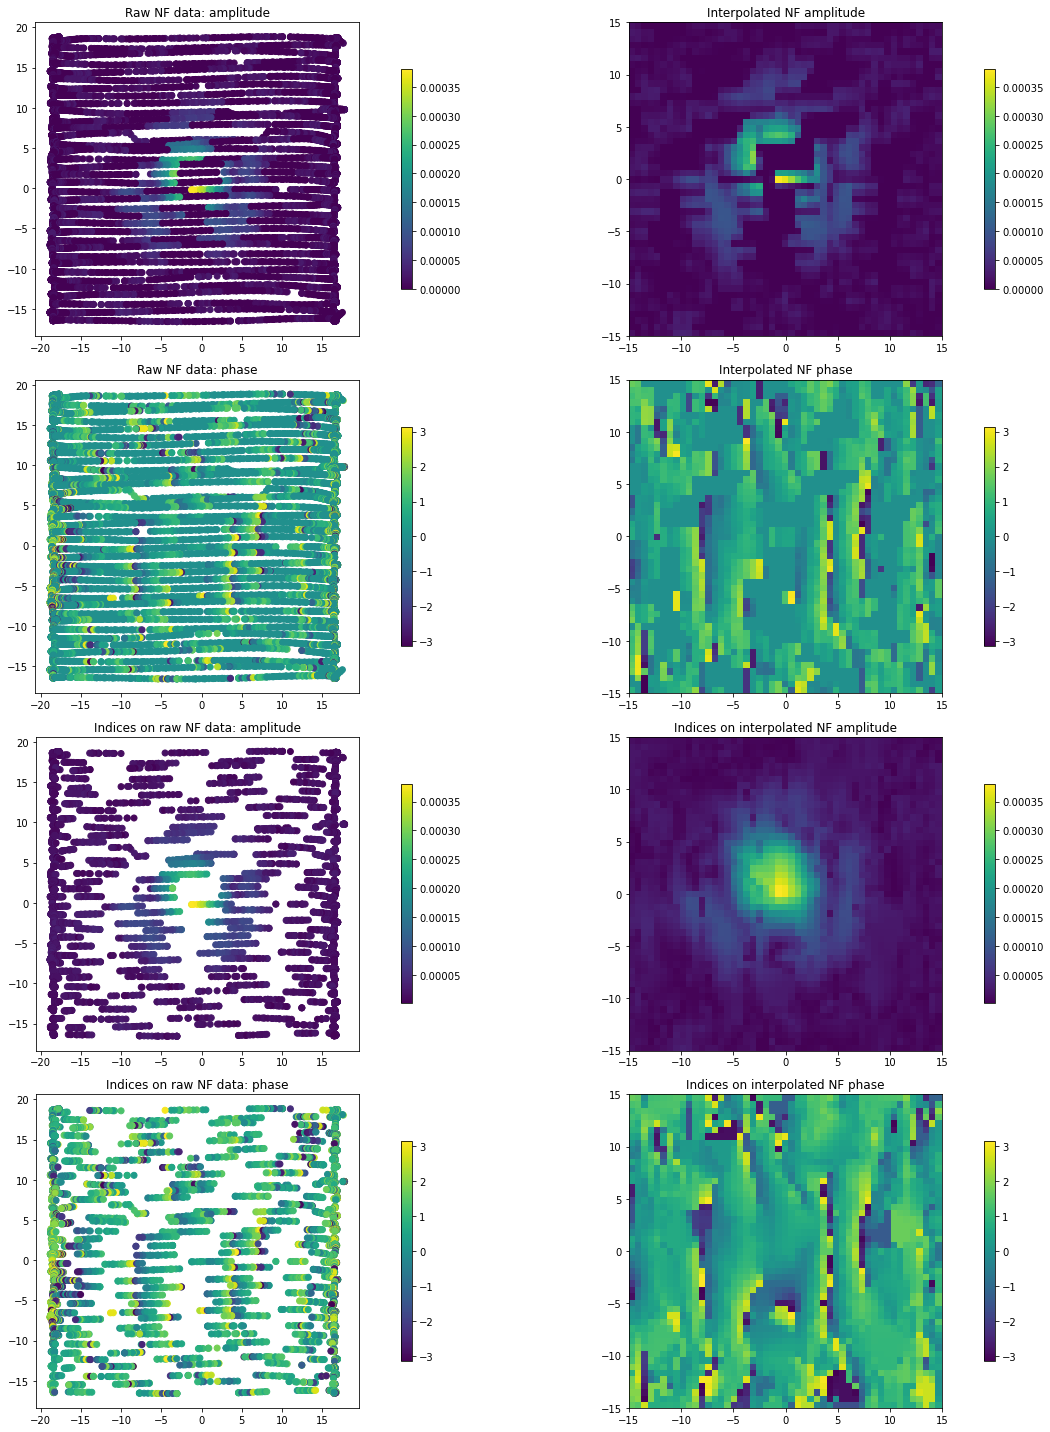

In [34]:
fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(4,2,1)
plt.scatter(NSpol_x_grid,NSpol_y_grid,c=np.abs(NSpol_NF_complex_grid[:,275]))
ax.set_aspect('equal')
plt.colorbar(shrink=0.7)
plt.title('Raw NF data: amplitude')
ax = fig.add_subplot(4,2,2)
ax.pcolormesh(x_interp_grid,y_interp_grid,NSpol_NF_interped_amplitude)
plt.title('Interpolated NF amplitude')
plt.colorbar(shrink=0.7)
ax.set_aspect('equal')
ax = fig.add_subplot(4,2,3)
plt.scatter(NSpol_x_grid,NSpol_y_grid,c=np.angle(NSpol_NF_complex_grid[:,275]))
ax.set_aspect('equal')
plt.colorbar(shrink=0.7)
plt.title('Raw NF data: phase')
ax = fig.add_subplot(4,2,4)
ax.pcolormesh(x_interp_grid,y_interp_grid,NSpol_NF_interped_phase)
plt.title('Interpolated NF phase')
plt.colorbar(shrink=0.7)
ax.set_aspect('equal')
plt.tight_layout()

ax = fig.add_subplot(4,2,5)
plt.scatter(NSpol_x_grid_selected,NSpol_y_grid_selected,c=np.abs(NSpol_NF_complex_grid_selected[:,275]))
ax.set_aspect('equal')
plt.colorbar(shrink=0.7)
plt.title('Indices on raw NF data: amplitude')
ax = fig.add_subplot(4,2,6)
ax.pcolormesh(x_interp_grid,y_interp_grid,NSpol_NF_interped_amplitude_selected)
plt.title('Indices on interpolated NF amplitude')
plt.colorbar(shrink=0.7)
ax.set_aspect('equal')
ax = fig.add_subplot(4,2,7)
plt.scatter(NSpol_x_grid_selected,NSpol_y_grid_selected,c=np.angle(NSpol_NF_complex_grid_selected[:,275]))
ax.set_aspect('equal')
plt.colorbar(shrink=0.7)
plt.title('Indices on raw NF data: phase')
ax = fig.add_subplot(4,2,8)
ax.pcolormesh(x_interp_grid,y_interp_grid,NSpol_NF_interped_phase_selected)
plt.title('Indices on interpolated NF phase')
plt.colorbar(shrink=0.7)
ax.set_aspect('equal')
plt.tight_layout()

plt.savefig('NSPol_NF_interpolated.jpg')

In [35]:
EWpol_NF_data['f']

array([800.      , 799.609375, 799.21875 , ..., 401.171875, 400.78125 ,
       400.390625])